# Gaussian Closed-Form Geometry (1D and 2D)

This notebook generates the Gaussian figures used in the paper:
- one-mode trajectories in the $(r,s)$ plane for $p\in\{1,2,4,\infty\}$,
- conserved leaves (separate PDFs),
- two-mode trajectories in `(r1,r2)` from white-noise initialization for several targets `beta=(beta1,beta2)`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

FIG_DIR = Path("../../neurips/figures/fig-gaussians")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 140,
        "font.size": 11,
        "axes.grid": True,
        "grid.alpha": 0.22,
        "axes.spines.top": True,
        "axes.spines.right": True,
    }
)


Matplotlib is building the font cache; this may take a moment.


In [2]:
TARGET = 1.0
# Initial points interpreted as canonical variables (r,s).
initial_points = [(-1.5, 1.8), (-0.5, 2.0)]
r0, s0 = initial_points[0]

r_range = (-1.9, 1.9)
s_range = (0.0, 2.8)
p_values = [1.0, 2.0, 4.0, np.inf]


def blue_red_color(t):
    t = float(np.clip(t, 0.0, 1.0))
    return (t, 0.0, 1.0 - t)


color_of = {}
for i, p in enumerate(p_values):
    tau = i / (len(p_values) - 1.0)
    color_of[p] = blue_red_color(tau)


def q_from_p(p):
    if np.isinf(p):
        return 1.0
    return 2.0 * float(p) / (2.0 * float(p) - 1.0)


def invariant_level(r_init, s_init, p):
    if p == 1:
        return s_init * s_init - r_init * r_init
    if np.isinf(p):
        a0 = s_init + r_init
        b0 = s_init - r_init
        return np.sqrt(a0) + np.sqrt(b0)
    p = float(p)
    exponent = (p - 1.0) / (2.0 * p - 1.0)
    a0 = s_init + r_init
    b0 = s_init - r_init
    return a0**exponent + b0**exponent


def solve_s_on_invariant(r, level, p):
    r = float(r)
    if p == 1:
        return np.sqrt(max(r * r + level, 0.0))
    if np.isinf(p):
        lo = abs(r) + 1e-12
        hi = max(lo + 1.0, 2.0)

        def residual(s):
            return np.sqrt(s + r) + np.sqrt(s - r) - level

        if residual(lo) > 0.0:
            return np.nan
        while residual(hi) < 0.0:
            hi *= 2.0
            if hi > 1e6:
                return np.nan

        for _ in range(90):
            mid = 0.5 * (lo + hi)
            if residual(mid) > 0.0:
                hi = mid
            else:
                lo = mid
        return 0.5 * (lo + hi)

    p = float(p)
    exponent = (p - 1.0) / (2.0 * p - 1.0)
    lo = abs(r) + 1e-12
    hi = max(lo + 1.0, 2.0)

    def residual(s):
        return (s + r) ** exponent + (s - r) ** exponent - level

    if residual(lo) > 0.0:
        return np.nan
    while residual(hi) < 0.0:
        hi *= 2.0
        if hi > 1e6:
            return np.nan

    for _ in range(90):
        mid = 0.5 * (lo + hi)
        if residual(mid) > 0.0:
            hi = mid
        else:
            lo = mid
    return 0.5 * (lo + hi)


def invariant_curve(level, p, r_dense):
    s_vals = np.array([solve_s_on_invariant(r, level, p) for r in r_dense], dtype=float)
    valid = np.isfinite(s_vals) & (s_vals > np.abs(r_dense))
    return r_dense[valid], s_vals[valid]


def rhs_ab_1d(a, b, p, target=TARGET):
    q = q_from_p(p)
    a = max(float(a), 0.0)
    b = max(float(b), 0.0)
    aq = a ** (0.5 * q)
    bq = b ** (0.5 * q)
    pref = (aq + bq) ** ((2.0 - q) / q)
    err = 0.5 * (a - b) - target
    # In one mode, N**(2-q) * psi_q(err) simplifies to err * pref.
    da = -2.0 * err * pref * aq
    db = 2.0 * err * pref * bq
    return da, db


def rk4_step_1d(a, b, dt, p, target=TARGET):
    def F(x, y):
        return rhs_ab_1d(x, y, p, target=target)

    k1a, k1b = F(a, b)
    k2a, k2b = F(a + 0.5 * dt * k1a, b + 0.5 * dt * k1b)
    k3a, k3b = F(a + 0.5 * dt * k2a, b + 0.5 * dt * k2b)
    k4a, k4b = F(a + dt * k3a, b + dt * k3b)

    a_new = a + (dt / 6.0) * (k1a + 2.0 * k2a + 2.0 * k3a + k4a)
    b_new = b + (dt / 6.0) * (k1b + 2.0 * k2b + 2.0 * k3b + k4b)
    return max(a_new, 0.0), max(b_new, 0.0)


def integrate_flow_1d(r_start, s_start, p, T=18.0, dt=2e-4):
    a = s_start + r_start
    b = s_start - r_start
    if not (a > 0.0 and b > 0.0):
        raise ValueError("Need s0 > |r0|.")

    steps = int(np.ceil(T / dt))
    r_hist = np.empty(steps + 1)
    s_hist = np.empty(steps + 1)
    r_hist[0] = r_start
    s_hist[0] = s_start
    for k in range(steps):
        a, b = rk4_step_1d(a, b, dt, p, target=TARGET)
        r_hist[k + 1] = 0.5 * (a - b)
        s_hist[k + 1] = 0.5 * (a + b)
    return r_hist, s_hist


traj_1d = {
    k: {p: integrate_flow_1d(r_init, s_init, p) for p in p_values}
    for k, (r_init, s_init) in enumerate(initial_points)
}


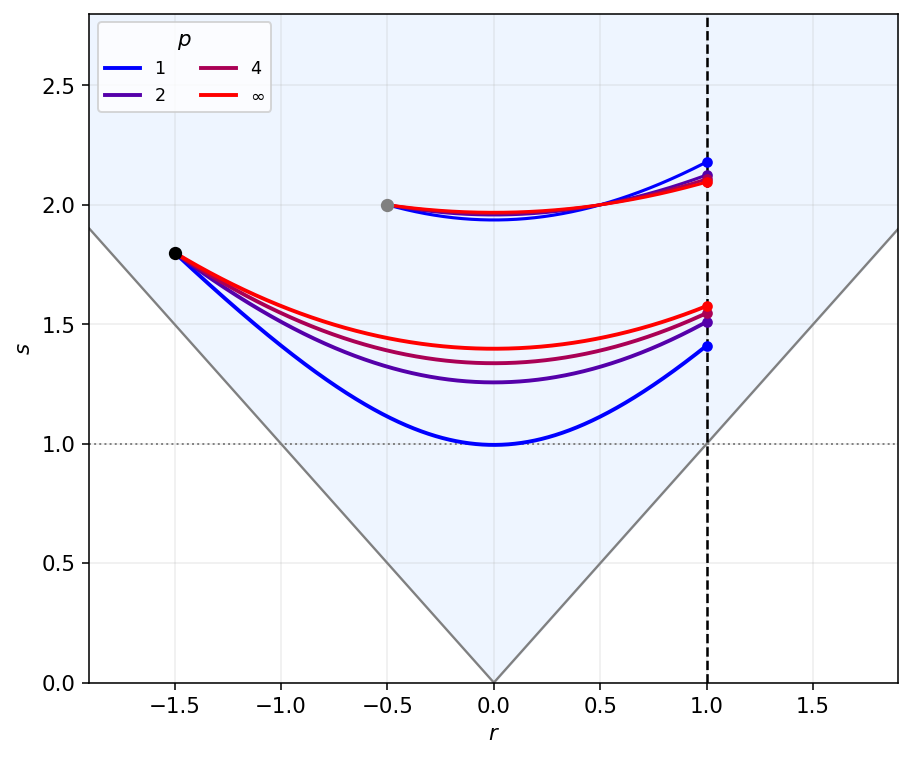

Saved: /Users/gpeyre/Dropbox/github/muon-dynamics/neurips/figures/fig-gaussians/gaussian_admissible_cone.pdf


In [3]:
# Figure 1: trajectories in the admissible cone for the selected p values.
fig, ax = plt.subplots(figsize=(6.4, 5.3), constrained_layout=True)

r_dense = np.linspace(r_range[0], r_range[1], 1600)
ax.fill_between(r_dense, np.abs(r_dense), s_range[1], color="#eef5ff", alpha=1.0)
ax.plot(r_dense, np.abs(r_dense), color="gray", lw=1.2)

ax.axvline(TARGET, color="black", linestyle="--", lw=1.3)
ax.axhline(1.0, color="gray", linestyle=":", lw=1.0)
ax.scatter([initial_points[0][0]], [initial_points[0][1]], c="black", s=34, zorder=3)
ax.scatter([initial_points[1][0]], [initial_points[1][1]], c="gray", s=34, zorder=3)

for p in p_values:
    r_hist, s_hist = traj_1d[0][p]
    c = color_of[p]
    label = r"$\infty$" if np.isinf(p) else rf"${p:g}$"
    ax.plot(r_hist, s_hist, color=c, lw=2.0, label=label)
    ax.scatter([r_hist[-1]], [s_hist[-1]], s=20, color=c, zorder=4)

    r_hist2, s_hist2 = traj_1d[1][p]
    ax.plot(r_hist2, s_hist2, color=c, lw=1.6)
    ax.scatter([r_hist2[-1]], [s_hist2[-1]], s=20, color=c, zorder=4)

ax.set_xlim(r_range)
ax.set_ylim(s_range)
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$s$")
ax.legend(loc="upper left", fontsize=9, title=r"$p$", ncol=2)

pdf1 = FIG_DIR / "gaussian_admissible_cone.pdf"
fig.savefig(pdf1, bbox_inches="tight")
plt.show()
print("Saved:", pdf1.resolve())


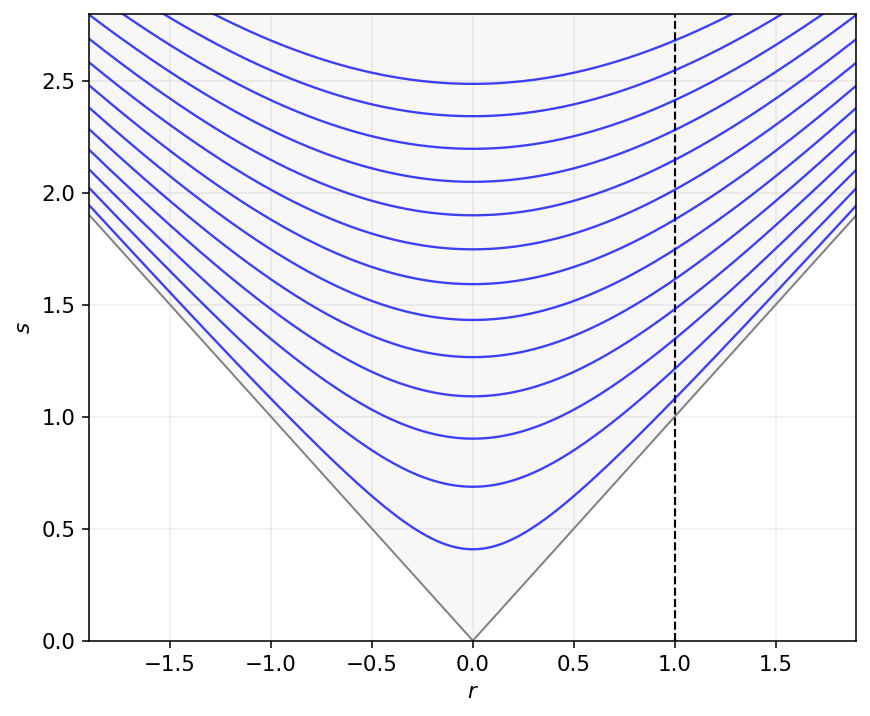

Saved: /Users/gpeyre/Dropbox/github/muon-dynamics/neurips/figures/fig-gaussians/gaussian_invariant_leaves_p1.pdf


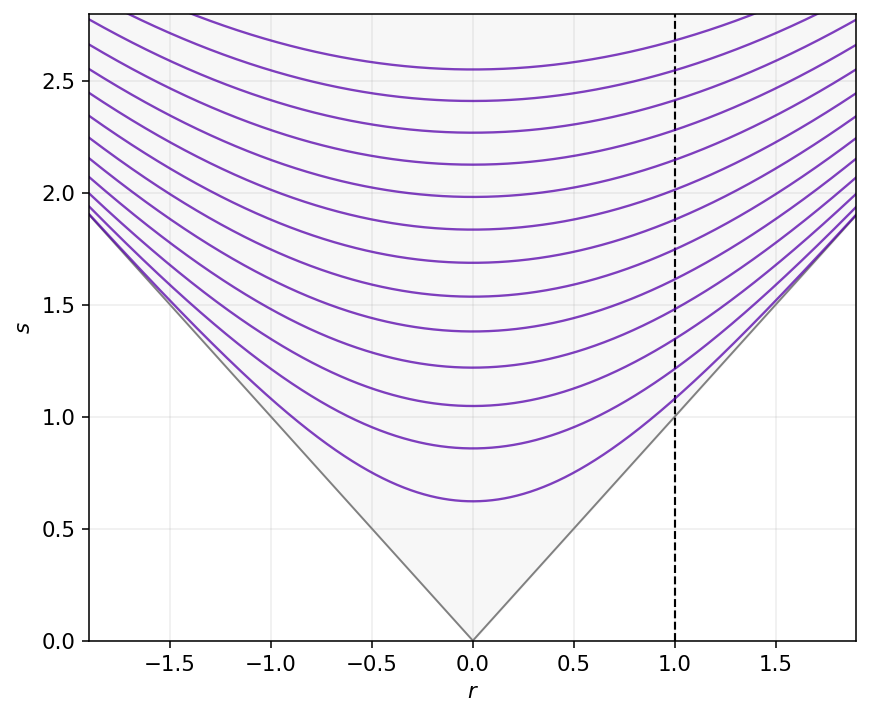

Saved: /Users/gpeyre/Dropbox/github/muon-dynamics/neurips/figures/fig-gaussians/gaussian_invariant_leaves_p2.pdf


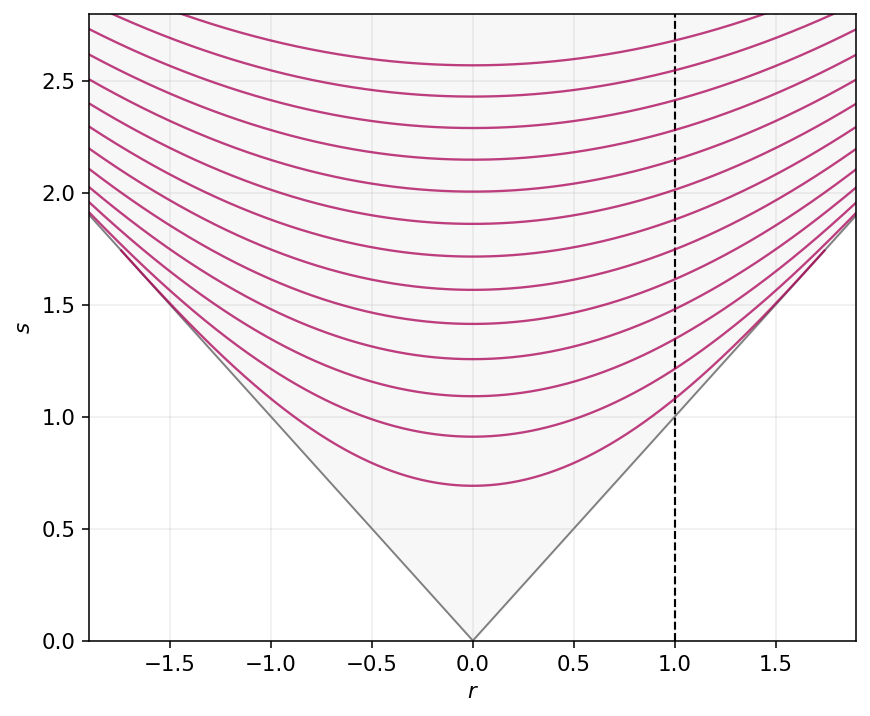

Saved: /Users/gpeyre/Dropbox/github/muon-dynamics/neurips/figures/fig-gaussians/gaussian_invariant_leaves_p4.pdf


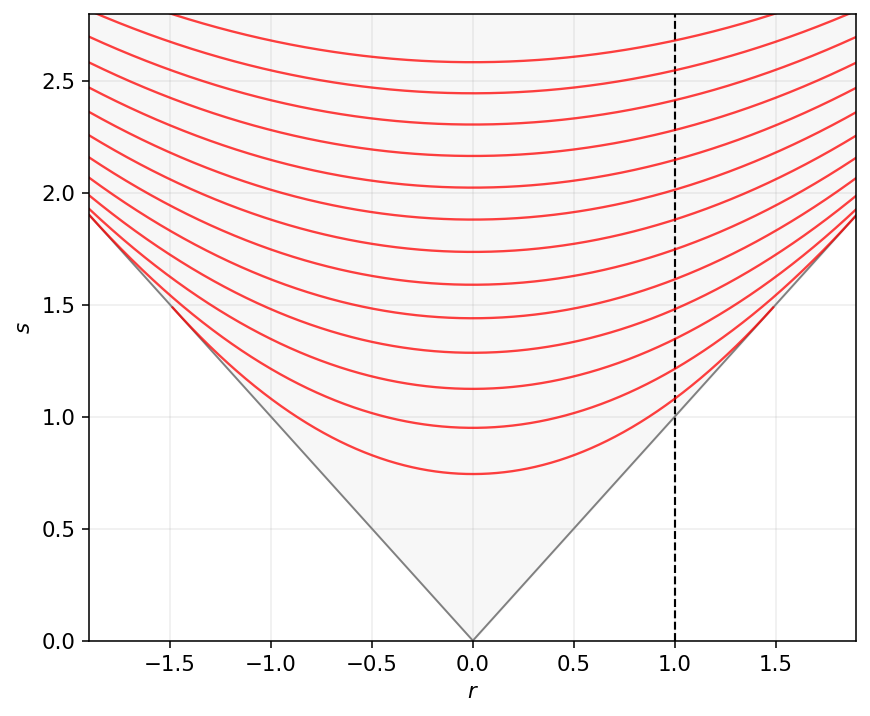

Saved: /Users/gpeyre/Dropbox/github/muon-dynamics/neurips/figures/fig-gaussians/gaussian_invariant_leaves_pinf.pdf


In [4]:
# Figure 2: separate conserved-leaf figures, one PDF per p.
r_dense = np.linspace(r_range[0], r_range[1], 2000)

for p in p_values:
    fig, ax = plt.subplots(figsize=(6.1, 5.0), constrained_layout=True)
    ax.fill_between(r_dense, np.abs(r_dense), s_range[1], color="#f7f7f7", alpha=1.0)
    ax.plot(r_dense, np.abs(r_dense), color="gray", lw=1.0)
    ax.axvline(TARGET, color="black", linestyle="--", lw=1.1)

    s_refs = np.linspace(abs(TARGET) + 0.08, s_range[1] - 0.12, 13)
    for s_ref in s_refs:
        level = invariant_level(TARGET, s_ref, p)
        rc, sc = invariant_curve(level, p, r_dense)
        ax.plot(rc, sc, color=color_of[p], lw=1.2, alpha=0.75)

    ax.set_xlim(r_range)
    ax.set_ylim(s_range)
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(r"$s$")
    if np.isinf(p):
        tag = "inf"
    else:
        tag = str(int(round(float(p))))
    pdf = FIG_DIR / f"gaussian_invariant_leaves_p{tag}.pdf"
    fig.savefig(pdf, bbox_inches="tight")
    plt.show()
    print("Saved:", pdf.resolve())


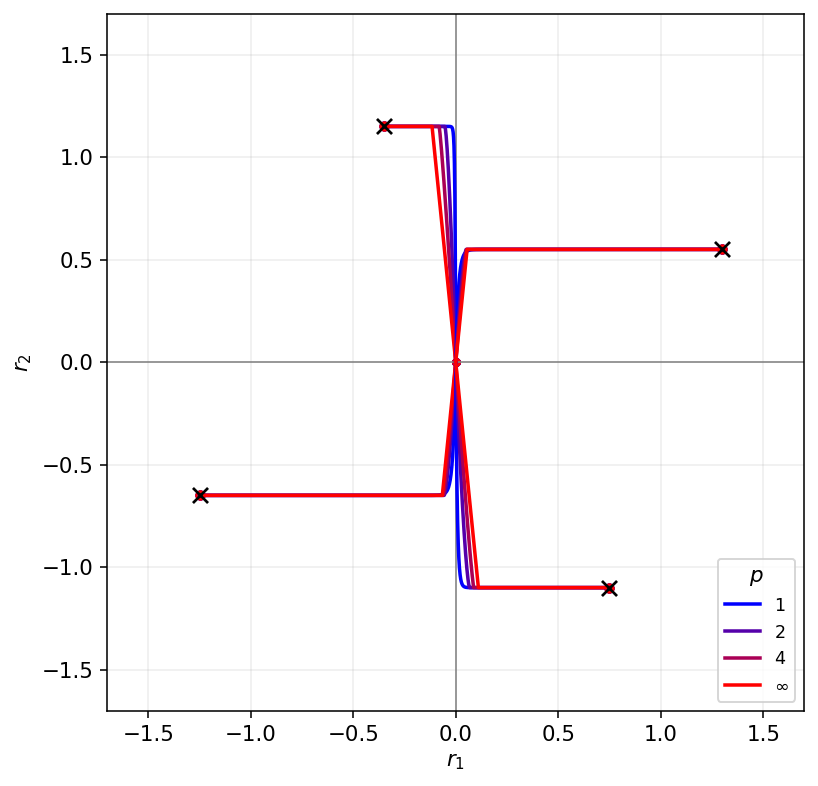

Saved: /Users/gpeyre/Dropbox/github/muon-dynamics/neurips/figures/fig-gaussians/gaussian_2d_rplane_targets.pdf


In [5]:
# Figure 3: two-mode dynamics on (r1,r2), with white-noise initialization.
# State: (a1,b1,a2,b2), where rj=(aj-bj)/2 and sj=(aj+bj)/2.
# Targets beta=(beta1,beta2) are spread in the (r1,r2) plane.
beta_list = [
    np.array([-1.25, -0.65]),
    np.array([-0.35, 1.15]),
    np.array([0.75, -1.10]),
    np.array([1.30, 0.55]),
]

# Balanced diagonal initialization in the reduced coordinates:
# all trajectories start from r=(0,0), s=(0.1,10.0).
r_init_2d = np.zeros(2, dtype=float)
s_init_2d = np.array([0.1, 10.0], dtype=float)


def rhs_ab_2d(a, b, p, beta):
    # a,b shape (2,), positive.
    q = q_from_p(p)
    a = np.maximum(np.asarray(a, dtype=float), 0.0)
    b = np.maximum(np.asarray(b, dtype=float), 0.0)
    r = 0.5 * (a - b)
    err = r - np.asarray(beta, dtype=float)
    aq = a ** (0.5 * q)
    bq = b ** (0.5 * q)
    norm_term = np.sum(np.abs(err) ** q * (aq + bq))
    if norm_term == 0.0:
        return np.zeros_like(a), np.zeros_like(b)
    pref = norm_term ** ((2.0 - q) / q)
    psi = np.sign(err) * np.abs(err) ** (q - 1.0)
    da = -2.0 * pref * psi * aq
    db = 2.0 * pref * psi * bq
    return da, db


def rk4_step_2d(a, b, dt, p, beta):
    def F(x, y):
        return rhs_ab_2d(x, y, p, beta)

    k1a, k1b = F(a, b)
    k2a, k2b = F(a + 0.5 * dt * k1a, b + 0.5 * dt * k1b)
    k3a, k3b = F(a + 0.5 * dt * k2a, b + 0.5 * dt * k2b)
    k4a, k4b = F(a + dt * k3a, b + dt * k3b)
    a_new = a + (dt / 6.0) * (k1a + 2.0 * k2a + 2.0 * k3a + k4a)
    b_new = b + (dt / 6.0) * (k1b + 2.0 * k2b + 2.0 * k3b + k4b)
    return np.maximum(a_new, 0.0), np.maximum(b_new, 0.0)


def integrate_flow_2d(beta, p, T=18.0, dt=2e-4):
    r0 = r_init_2d.copy()
    s0 = s_init_2d.copy()
    a = s0 + r0
    b = s0 - r0

    steps = int(np.ceil(T / dt))
    r_hist = np.empty((steps + 1, 2))
    s_hist = np.empty((steps + 1, 2))
    r_hist[0] = r0
    s_hist[0] = s0
    for k in range(steps):
        a, b = rk4_step_2d(a, b, dt, p, beta)
        r_hist[k + 1] = 0.5 * (a - b)
        s_hist[k + 1] = 0.5 * (a + b)
    return r_hist, s_hist


fig, ax = plt.subplots(figsize=(6.2, 5.5), constrained_layout=True)
ax.axhline(0.0, color="gray", lw=0.8)
ax.axvline(0.0, color="gray", lw=0.8)

for beta in beta_list:
    ax.scatter([beta[0]], [beta[1]], marker="x", s=60, c="black", linewidths=1.4, zorder=5)
    for p in p_values:
        r_hist, _ = integrate_flow_2d(beta, p)
        c = color_of[p]
        label = None
        if np.allclose(beta, beta_list[0]):
            label = r"$\infty$" if np.isinf(p) else rf"${p:g}$"
        ax.plot(r_hist[:, 0], r_hist[:, 1], color=c, lw=1.8, label=label)
        ax.scatter([r_hist[0, 0]], [r_hist[0, 1]], c=[c], s=12)
        ax.scatter([r_hist[-1, 0]], [r_hist[-1, 1]], c=[c], s=18)

ax.set_xlabel(r"$r_1$")
ax.set_ylabel(r"$r_2$")
ax.legend(loc="lower right", fontsize=9, title=r"$p$")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.7, 1.7)
ax.set_ylim(-1.7, 1.7)

pdf = FIG_DIR / "gaussian_2d_rplane_targets.pdf"
fig.savefig(pdf, bbox_inches="tight")
plt.show()
print("Saved:", pdf.resolve())
